In [1]:
import sys
import cv2
import torch
from matplotlib import pyplot as plt
import torch
# from efficientnet_pytorch import EfficientNet
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torch import nn, optim
import numpy as np
import os
import argparse
from tqdm import tqdm
from sklearn.model_selection import train_test_split  
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import re

from PIL import Image
from torch.nn import functional as F

import cv2
import torch
import os
from tqdm import tqdm
import ptlflow
from ptlflow.utils import flow_utils
import re
import numpy as np
import concurrent.futures
import timm
import time 
import random

d:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\venv\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[!!alt_cuda_corr is not compiled!!]


# Load Frames

In [2]:

frames_dir = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\frames\\'

frames = os.listdir(frames_dir)
print(f"Total frames: {len(frames)}")


Total frames: 9135


In [3]:

def natural_sort_key(s):
    return int(re.search(r'(\d+)', s).group())

frames = sorted(os.listdir(frames_dir), key=natural_sort_key)

# Check actual frame count
print(f"Total frames: {len(frames)}")
print(f"First frame: {frames[0]}")
print(f"Last frame: {frames[-1]}")
print(f"Expected last frame: frame_{len(frames)-1}.jpg")
print(frames[:20])


Total frames: 9135
First frame: frame_0.png
Last frame: frame_9134.png
Expected last frame: frame_9134.jpg
['frame_0.png', 'frame_1.png', 'frame_2.png', 'frame_3.png', 'frame_4.png', 'frame_5.png', 'frame_6.png', 'frame_7.png', 'frame_8.png', 'frame_9.png', 'frame_10.png', 'frame_11.png', 'frame_12.png', 'frame_13.png', 'frame_14.png', 'frame_15.png', 'frame_16.png', 'frame_17.png', 'frame_18.png', 'frame_19.png']


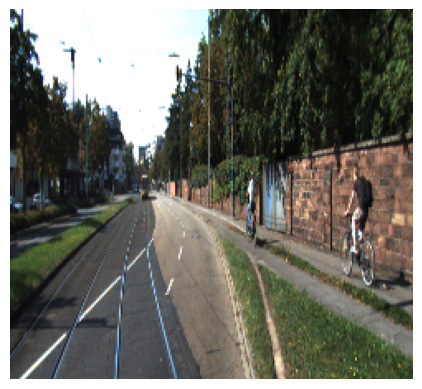

In [50]:
img = cv2.imread(os.path.join(frames_dir, frames[0]))
img = cv2.resize(img, (244, 224))   
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Train Test Split

In [7]:
def create__indices(folder, random_state=42):
    image_files = [f for f in os.listdir(folder) if f.startswith('frame_') and f.endswith('.png')]
    indices = [int(f.split('_')[1].split('.')[0]) for f in image_files]
    
    indices = sorted(indices)

    # random.seed(random_state)
    # random.shuffle(indices)
    return indices


train_indices = create__indices(r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\frames', random_state=42)
val_indices =   create__indices(r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\frames', random_state=42)

train_indices.remove(max(train_indices))
val_indices.remove(max(val_indices))

print(f"\nTrain indices: {train_indices[:10]} ... Total: {len(train_indices)}")
print(f"Val indices: {val_indices[:10]} ... Total: {len(val_indices)}")



Train indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... Total: 9134
Val indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... Total: 2123


# Dataloader

In [8]:

class PreprocessedSpeedDataset(Dataset):
    def __init__(self, folder, speed_file, indices=None, transform=None):
        self.folder = folder
        self.transform = transform  

        if indices:
            self.frame_files = [os.path.join(folder, f'frame_{idx}.png') for idx in indices]
        else:
            self.frame_files = [os.path.join(folder, f'frame_{idx}.png') for idx in range(len(os.listdir(folder)))]

        all_speeds = [float(speed) for speed in open(speed_file).read().splitlines()]
        self.speed_files = [all_speeds[idx+1] for idx in indices] if indices else all_speeds
        
    
    def __len__(self):
        return len(self.frame_files)
    
    def __getitem__(self, idx):
        image = plt.imread(self.frame_files[idx])[:, :, :3]  # Ensure RGB format

        speed = self.speed_files[idx]
        speed = torch.tensor(speed, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)

        return image, speed



transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
])



In [9]:


train_frame_dir = r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\frames"
val_frame_dir =   r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\frames"

train_speed_dir = r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\frame_speeds.txt"
val_speed_dir =   r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\frame_speeds.txt"

train_dataset = PreprocessedSpeedDataset(train_frame_dir, train_speed_dir, train_indices, transform=transform)
val_dataset = PreprocessedSpeedDataset(val_frame_dir, val_speed_dir, val_indices, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, num_workers=0, shuffle=True, pin_memory=True)   # * 64 best, 32 2nd best
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=0, pin_memory=True)


IndexError: index 77 is out of bounds for dimension 0 with size 16

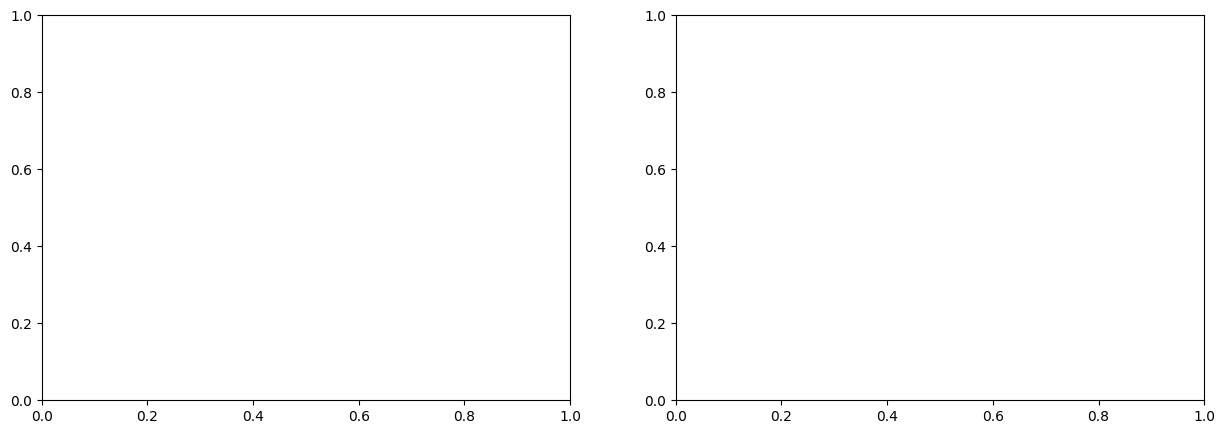

In [84]:
idx = 77
# idx = 0

# Create subplots to display frame0, frame1, flow, and speed
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Load and display frame0
frame0_path = os.path.join(frames_dir, frames[idx])
frame0 = cv2.imread(frame0_path)
frame0_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)
frame0 = cv2.resize(frame0, (224, 224))
frame0_processed_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)

axs[0].imshow(frame0_processed_rgb)
axs[0].set_title('Frame 0 (Processed)')
axs[0].axis('off')

# Load and display frame1
frame1_path = os.path.join(frames_dir, frames[idx + 1])
frame1 = cv2.imread(frame1_path)
frame1 = cv2.resize(frame1, (224, 224))
frame1_processed_rgb = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)

axs[1].imshow(frame1_processed_rgb)
axs[1].set_title('Frame 1 (Processed)')
axs[1].axis('off')

# Get speed value from dataset
speed_value = train_dataset[idx][1].item()
fig.suptitle(f'Speed: {speed_value:.2f} km/h', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

print(f"Speed value: {speed_value:.2f}")
print(f"Dataset returns: image tensor of shape {train_dataset[idx][0].shape}, speed value {speed_value}")

# Train Model

# ConvLSTM

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm
import cv2
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
from torch.amp import autocast, GradScaler

class ConsecutiveFramesDataset(Dataset):
    def __init__(self, folder, speed_file, indices=None, transform=None):
        self.folder = folder
        self.transform = transform
        
        if indices:
            # Remove the last index to ensure we have pairs
            self.indices = [idx for idx in indices if idx < max(indices)]
        else:
            all_files = os.listdir(folder)
            max_idx = len(all_files) - 1
            self.indices = list(range(max_idx))
        
        # Load speeds
        all_speeds = [float(speed) for speed in open(speed_file).read().splitlines()]
        self.speeds = [all_speeds[idx+1] for idx in self.indices]  # +1 for ground truth alignment
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        frame_idx = self.indices[idx]
        
        # Load consecutive frames
        frame1_path = os.path.join(self.folder, f'frame_{frame_idx}.png')
        frame2_path = os.path.join(self.folder, f'frame_{frame_idx + 1}.png')
        
        frame1 = plt.imread(frame1_path)[:, :, :3]  # RGB
        frame2 = plt.imread(frame2_path)[:, :, :3]  # RGB
        
        speed = torch.tensor(self.speeds[idx], dtype=torch.float32)
        
        if self.transform:
            frame1 = self.transform(frame1)
            frame2 = self.transform(frame2)
        else:
            frame1 = transforms.ToTensor()(frame1)
            frame2 = transforms.ToTensor()(frame2)
        
        # Stack frames: [2, 3, H, W]
        frames = torch.stack([frame1, frame2], dim=0)
        
        return frames, speed

# ConvLSTM implementation
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias=True):
        super(ConvLSTMCell, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.padding = kernel_size[0] // 2, kernel_size[1] // 2
        self.bias = bias
        
        self.conv = nn.Conv2d(
            in_channels=self.input_dim + self.hidden_dim,
            out_channels=4 * self.hidden_dim,
            kernel_size=self.kernel_size,
            padding=self.padding,
            bias=self.bias
        )
    
    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state
        
        # Concatenate along channel axis
        combined = torch.cat([input_tensor, h_cur], dim=1)
        
        combined_conv = self.conv(combined)
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        
        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)
        
        c_next = f * c_cur + i * g
        h_next = o * torch.tanh(c_next)
        
        return h_next, c_next
    
    def init_hidden(self, batch_size, image_size):
        height, width = image_size
        return (torch.zeros(batch_size, self.hidden_dim, height, width, device=self.conv.weight.device),
                torch.zeros(batch_size, self.hidden_dim, height, width, device=self.conv.weight.device))

class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, bias=True):
        super(ConvLSTM, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.num_layers = num_layers
        self.bias = bias
        
        cell_list = []
        for i in range(0, self.num_layers):
            cur_input_dim = self.input_dim if i == 0 else self.hidden_dim[i-1]
            
            cell_list.append(ConvLSTMCell(
                input_dim=cur_input_dim,
                hidden_dim=self.hidden_dim[i],
                kernel_size=self.kernel_size,
                bias=self.bias
            ))
        
        self.cell_list = nn.ModuleList(cell_list)
    
    def forward(self, input_tensor):
        # input_tensor: [batch, seq_len, channels, height, width]
        b, seq_len, _, h, w = input_tensor.size()
        
        # Initialize hidden states
        hidden_state = []
        for i in range(self.num_layers):
            hidden_state.append(self.cell_list[i].init_hidden(b, (h, w)))
        
        layer_output_list = []
        last_state_list = []
        
        cur_layer_input = input_tensor
        
        for layer_idx in range(self.num_layers):
            h, c = hidden_state[layer_idx]
            output_inner = []
            
            for t in range(seq_len):
                h, c = self.cell_list[layer_idx](cur_layer_input[:, t, :, :, :], (h, c))
                output_inner.append(h)
            
            layer_output = torch.stack(output_inner, dim=1)
            cur_layer_input = layer_output
            
            layer_output_list.append(layer_output)
            last_state_list.append((h, c))
        
        return layer_output_list[-1], last_state_list

class SpeedEstimationModel(nn.Module):
    def __init__(self, backbone='efficientnetv2_rw_t', pretrained=True, convlstm_hidden_dim=[64, 32], dropout=0.3):
        super(SpeedEstimationModel, self).__init__()
        
        # Feature extractor
        self.backbone = timm.create_model(backbone, pretrained=pretrained, features_only=True)
        
        # Get feature dimensions
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224)
            features = self.backbone(dummy_input)
            # Use features from middle layers for better spatial resolution
            self.feature_dim = features[2].shape[1]  # Usually around 48-64 channels
            self.feature_size = features[2].shape[2:]  # Spatial dimensions
        
        # ConvLSTM for temporal modeling
        self.convlstm = ConvLSTM(
            input_dim=self.feature_dim,
            hidden_dim=convlstm_hidden_dim,
            kernel_size=(3, 3),
            num_layers=len(convlstm_hidden_dim),
            bias=True
        )
        
        # Global average pooling and regression head
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Sequential(
            nn.Linear(convlstm_hidden_dim[-1], 128),
            nn.ReLU(),
            nn.Dropout(dropout/2),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        # x: [batch, seq_len, channels, height, width]
        batch_size, seq_len = x.shape[:2]
        
        # Extract features for each frame
        features_list = []
        for t in range(seq_len):
            frame_features = self.backbone(x[:, t])
            # Use middle layer features (index 2) for better spatial info
            features_list.append(frame_features[2])
        
        # Stack features: [batch, seq_len, channels, height, width]
        features = torch.stack(features_list, dim=1)
        
        # Pass through ConvLSTM
        lstm_output, _ = self.convlstm(features)
        
        # Use final timestep output
        final_features = lstm_output[:, -1]  # [batch, hidden_dim, height, width]
        
        # Global pooling and regression
        pooled = self.global_pool(final_features).squeeze(-1).squeeze(-1)
        pooled = self.dropout(pooled)
        speed = self.regressor(pooled)
        
        return speed


# Low-level feature extraction model
class SpeedEstimationModel_low_level(nn.Module):
    def __init__(self, backbone='efficientnetv2_rw_t', pretrained=True, convlstm_hidden_dim=[32, 16], dropout=0.3):
        super(SpeedEstimationModel_low_level, self).__init__()
        
        # Feature extractor
        self.backbone = timm.create_model(backbone, pretrained=pretrained, features_only=True)
        
        # Get feature dimensions from EARLY layers for low-level features
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224)
            features = self.backbone(dummy_input)
            
            # Use layer 0 or 1 for low-level features (edges, corners, textures)
            # Layer 0: Very low-level (edges, basic patterns) - highest resolution
            # Layer 1: Low-level (corners, simple shapes) - high resolution
            self.feature_dim = features[0].shape[1]  # Changed from [2] to [0] for lowest level
            self.feature_size = features[0].shape[2:]  # Spatial dimensions
            
            print(f"Using feature layer 0:")
            print(f"Feature dimensions: {self.feature_dim} channels")
            print(f"Spatial size: {self.feature_size}")
            print(f"All layer shapes:")
            for i, feat in enumerate(features):
                print(f"  Layer {i}: {feat.shape}")
        
        # ConvLSTM for temporal modeling of low-level features
        # Reduced hidden dimensions since we're working with low-level features
        self.convlstm = ConvLSTM(
            input_dim=self.feature_dim,
            hidden_dim=convlstm_hidden_dim,
            kernel_size=(3, 3),  # Small kernel to preserve spatial detail
            num_layers=len(convlstm_hidden_dim),
            bias=True
        )
        
        # Global average pooling and regression head
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        
        # Simpler regression head for low-level feature processing
        self.regressor = nn.Sequential(
            nn.Linear(convlstm_hidden_dim[-1], 64),
            nn.ReLU(),
            nn.Dropout(dropout/2),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        # x: [batch, seq_len, channels, height, width]
        batch_size, seq_len = x.shape[:2]
        
        # Extract LOW-LEVEL features for each frame
        features_list = []
        for t in range(seq_len):
            frame_features = self.backbone(x[:, t])
            # Use layer 0 for lowest-level features (edges, corners)
            features_list.append(frame_features[0])  # Changed from [2] to [0]
        
        # Stack features: [batch, seq_len, channels, height, width]
        features = torch.stack(features_list, dim=1)
        
        # Pass through ConvLSTM to learn temporal changes in low-level features
        lstm_output, _ = self.convlstm(features)
        
        # Use final timestep output
        final_features = lstm_output[:, -1]  # [batch, hidden_dim, height, width]
        
        # Global pooling and regression
        pooled = self.global_pool(final_features).squeeze(-1).squeeze(-1)
        pooled = self.dropout(pooled)
        speed = self.regressor(pooled)
        
        return speed

# Alternative: Use multiple low-level layers for richer feature representation
class MultiLevelSpeedEstimationModel(nn.Module):
    def __init__(self, backbone='efficientnetv2_rw_t', pretrained=True, convlstm_hidden_dim=[32, 16], dropout=0.3):
        super(MultiLevelSpeedEstimationModel, self).__init__()
        
        self.backbone = timm.create_model(backbone, pretrained=pretrained, features_only=True)
        
        # Get dimensions for multiple low-level layers
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224)
            features = self.backbone(dummy_input)
            
            # Combine layer 0 and 1 for comprehensive low-level features
            self.layer0_dim = features[0].shape[1]
            self.layer1_dim = features[1].shape[1]
            self.combined_dim = self.layer0_dim + self.layer1_dim
            
            print(f"Layer 0 (edges): {features[0].shape}")
            print(f"Layer 1 (corners): {features[1].shape}")
            print(f"Combined channels: {self.combined_dim}")
        
        # Fusion layer to combine low-level features
        self.feature_fusion = nn.Conv2d(
            self.combined_dim, 
            convlstm_hidden_dim[0], 
            kernel_size=1, 
            bias=True
        )
        
        # ConvLSTM for temporal modeling
        self.convlstm = ConvLSTM(
            input_dim=convlstm_hidden_dim[0],
            hidden_dim=convlstm_hidden_dim,
            kernel_size=(3, 3),
            num_layers=len(convlstm_hidden_dim),
            bias=True
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Sequential(
            nn.Linear(convlstm_hidden_dim[-1], 64),
            nn.ReLU(),
            nn.Dropout(dropout/2),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        batch_size, seq_len = x.shape[:2]
        
        features_list = []
        for t in range(seq_len):
            frame_features = self.backbone(x[:, t])
            
            # Resize layer 1 to match layer 0 spatial dimensions
            layer0_feat = frame_features[0]  # High resolution edges
            layer1_feat = frame_features[1]  # Lower resolution corners
            
            # Upsample layer 1 to match layer 0 size
            layer1_upsampled = F.interpolate(
                layer1_feat, 
                size=layer0_feat.shape[2:], 
                mode='bilinear', 
                align_corners=False
            )
            
            # Concatenate low-level features
            combined_features = torch.cat([layer0_feat, layer1_upsampled], dim=1)
            
            # Fuse features
            fused_features = self.feature_fusion(combined_features)
            features_list.append(fused_features)
        
        # Stack and process through ConvLSTM
        features = torch.stack(features_list, dim=1)
        lstm_output, _ = self.convlstm(features)
        
        final_features = lstm_output[:, -1]
        pooled = self.global_pool(final_features).squeeze(-1).squeeze(-1)
        pooled = self.dropout(pooled)
        speed = self.regressor(pooled)
        
        return speed


def validate_model(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for frames, speeds in val_loader:
            frames = frames.to(device)
            speeds = speeds.to(device)
            
            outputs = model(frames)
            loss = criterion(outputs.squeeze(), speeds)
            val_loss += loss.item()
    
    return val_loss / len(val_loader)


In [11]:

# Update your dataset creation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Remove last index to ensure consecutive pairs
train_indices_filtered = [idx for idx in train_indices if idx < max(train_indices)]
val_indices_filtered = [idx for idx in val_indices if idx < max(val_indices)]

train_dataset = ConsecutiveFramesDataset(train_frame_dir, train_speed_dir, train_indices_filtered, transform=transform)
val_dataset = ConsecutiveFramesDataset(val_frame_dir, val_speed_dir, val_indices_filtered, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpeedEstimationModel(
    backbone='efficientnetv2_rw_t',  # Fast and efficient
    pretrained=True,
    convlstm_hidden_dim=[64, 32],
    dropout=0.5
).to(device)

# Option 1: Single low-level layer (simpler)
# model = SpeedEstimationModel(
#     backbone='efficientnetv2_rw_t',
#     pretrained=True,
#     convlstm_hidden_dim=[32, 16],  # Reduced for low-level features
#     dropout=0.3
# ).to(device)

# Option 2: Multi-level low-level features (more comprehensive)
# model = MultiLevelSpeedEstimationModel(
#     backbone='efficientnetv2_rw_t',
#     pretrained=True,
#     convlstm_hidden_dim=[32, 16],
#     dropout=0.3
# ).to(device)

# FREEZE THE BACKBONE - Only train ConvLSTM
for param in model.backbone.parameters():
    param.requires_grad = False

# Training setup
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)
scheduler = optim.lr_scheduler.ReduceLROnPlateau( optimizer,  mode='min',  factor=0.3,  patience=2, verbose=True, min_lr=1e-8 )
scaler = GradScaler()

print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")


Unexpected keys (bn2.bias, bn2.num_batches_tracked, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
d:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Model parameters: 377,409
Training dataset size: 9132
Validation dataset size: 2121


Epoch 1/10: 100%|██████████| 571/571 [04:01<00:00,  2.36it/s, Loss=11.3834, L2=27.2976, LR=1.0e-04] 



New best model saved! Val Loss: 37.2172
Epoch 1/10
Train Loss: 44.6016, Val Loss: 37.2172
Gap: -7.3844, LR: 1.0e-04
Patience: 0/5



Epoch 2/10: 100%|██████████| 571/571 [03:02<00:00,  3.13it/s, Loss=4.8558, L2=28.3629, LR=1.0e-04] 



New best model saved! Val Loss: 27.9731
Epoch 2/10
Train Loss: 13.7413, Val Loss: 27.9731
Gap: 14.2318, LR: 1.0e-04
Patience: 0/5



Epoch 3/10: 100%|██████████| 571/571 [02:55<00:00,  3.26it/s, Loss=6.4803, L2=28.9057, LR=1.0e-04] 


...


New best model saved! Val Loss: 24.2996
Epoch 8/10
Train Loss: 4.3262, Val Loss: 24.2996
Gap: 19.9734, LR: 1.0e-04
Patience: 0/5



Epoch 9/10: 100%|██████████| 571/571 [02:57<00:00,  3.22it/s, Loss=4.9697, L2=30.7322, LR=1.0e-04] 


Epoch 9/10
Train Loss: 3.7451, Val Loss: 32.3770
Gap: 28.6319, LR: 1.0e-04
Patience: 1/5



Epoch 10/10: 100%|██████████| 571/571 [03:07<00:00,  3.04it/s, Loss=1.5707, L2=31.0707, LR=1.0e-04] 



New best model saved! Val Loss: 24.0105
Epoch 10/10
Train Loss: 3.4010, Val Loss: 24.0105
Gap: 20.6095, LR: 1.0e-04
Patience: 0/5

Training completed in 38.27 minutes
Best validation loss: 24.0105


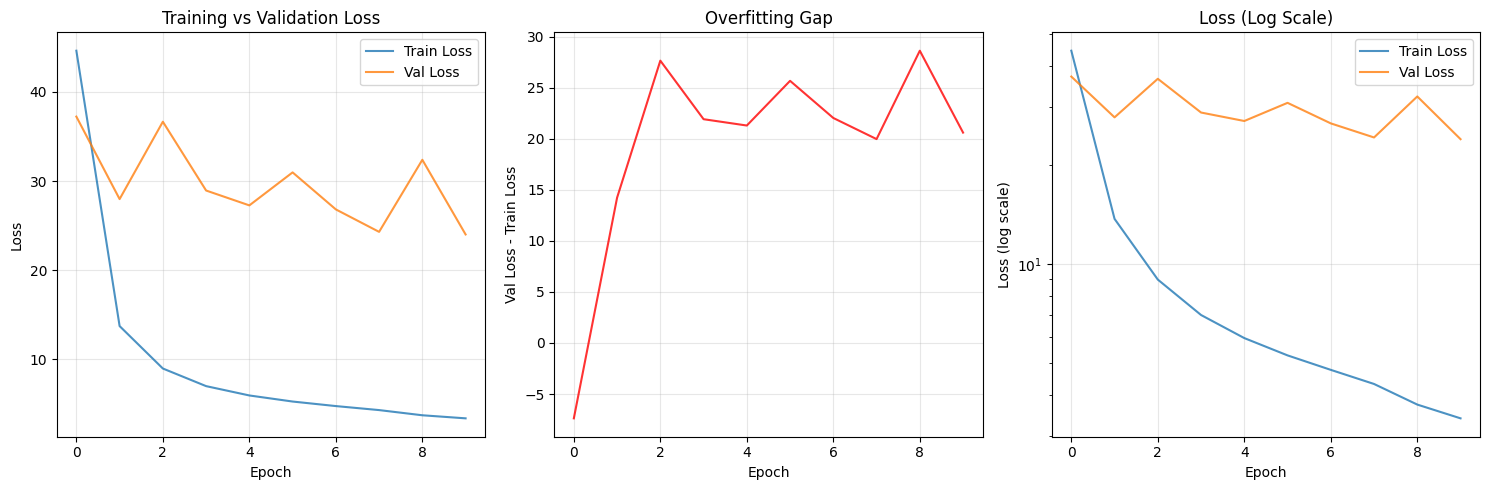

In [12]:

# 3. IMPROVED TRAINING LOOP WITH STRONGER REGULARIZATION
num_epochs = 10  # Fewer epochs
best_loss = float('inf')
start_time = time.time()

train_losses = []
val_losses = []
patience_counter = 0
max_patience = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    
    for batch_idx, (frames, speeds) in enumerate(pbar):
        frames = frames.to(device)
        speeds = speeds.to(device)
        
        optimizer.zero_grad()
        
        with autocast('cuda'):
            outputs = model(frames)
            base_loss = criterion(outputs.squeeze(), speeds)
            
            # Very strong L2 regularization
            l2_lambda = 0.01  # 10x stronger
            l2_reg = torch.tensor(0.0, device=device)
            for name, param in model.named_parameters():
                if 'convlstm' in name or 'regressor' in name:
                    if param.requires_grad:
                        l2_reg += torch.norm(param, 2)
            
            # Add dropout regularization to features
            total_loss = base_loss + l2_lambda * l2_reg
        
        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        
        # Very aggressive gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += base_loss.item()
        pbar.set_postfix({
            'Loss': f'{base_loss.item():.4f}',
            'L2': f'{l2_reg.item():.4f}',
            'LR': f'{optimizer.param_groups[0]["lr"]:.1e}'
        })
    
    avg_train_loss = running_loss / len(train_loader)
    
    # Simple validation (no averaging to get true performance)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for frames, speeds in val_loader:
            frames = frames.to(device)
            speeds = speeds.to(device)
            outputs = model(frames)
            loss = criterion(outputs.squeeze(), speeds)
            val_loss += loss.item()
    
    val_loss = val_loss / len(val_loader)
    
    # Track losses
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    
    # Step scheduler
    scheduler.step(val_loss)
    
    # Save best model
    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'train_loss': avg_train_loss
        }, 'best_convlstm_speed_model.pth')
        print(f"\nNew best model saved! Val Loss: {val_loss:.4f}")
    else:
        patience_counter += 1
    
    gap = val_loss - avg_train_loss
    
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}')
    print(f'Gap: {gap:.4f}, LR: {optimizer.param_groups[0]["lr"]:.1e}')
    print(f'Patience: {patience_counter}/{max_patience}\n')
    
    # # Early stopping based on no improvement
    if patience_counter >= max_patience:
        print(f"Early stopping: No improvement for {max_patience} epochs")
        break
    
    # # Stop if gap is too large
    if gap > 15:
        print(f"Stopping: Overfitting gap too large ({gap:.2f})")
        break
    
torch.cuda.empty_cache()

end_time = time.time()
print(f"Training completed in {(end_time - start_time)/60:.2f} minutes")
print(f"Best validation loss: {best_loss:.4f}")


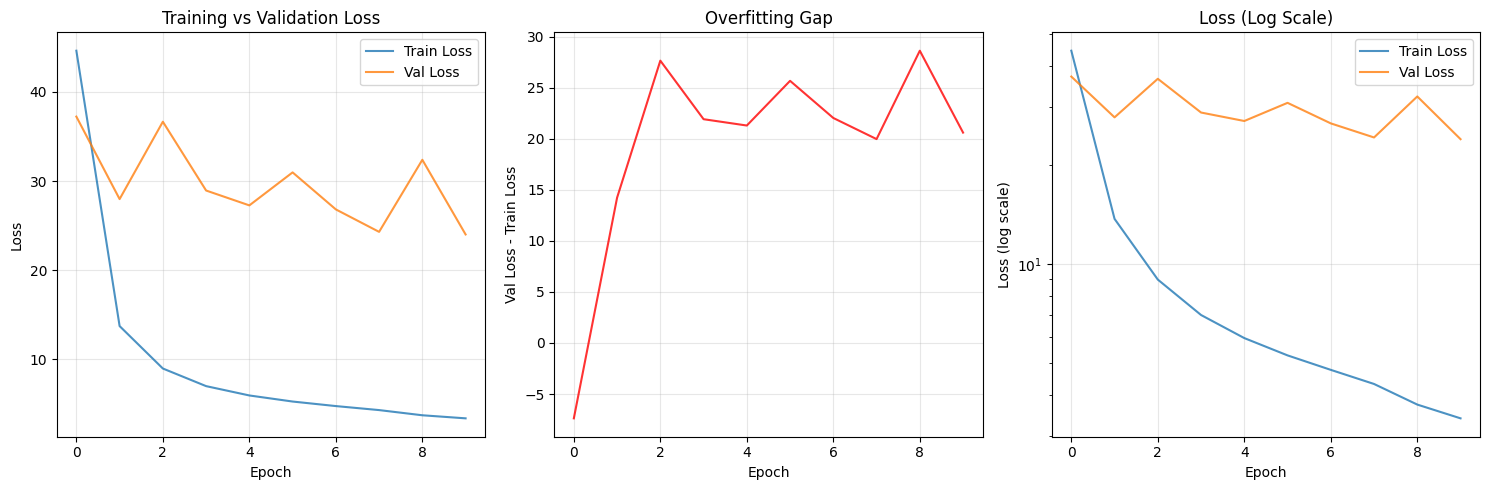

In [13]:
# Plot results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', alpha=0.8)
plt.plot(val_losses, label='Val Loss', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
gaps = [val - train for val, train in zip(val_losses, train_losses)]
plt.plot(gaps, color='red', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Val Loss - Train Loss')
plt.title('Overfitting Gap')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
if len(train_losses) > 1:
    plt.semilogy(train_losses, label='Train Loss', alpha=0.8)
    plt.semilogy(val_losses, label='Val Loss', alpha=0.8)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.title('Loss (Log Scale)')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Simpler Training Loop

In [71]:

# Training loop
num_epochs = 50
best_loss = float('inf')

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    
    for batch_idx, (frames, speeds) in enumerate(pbar):
        frames = frames.to(device)  # [batch, seq_len, channels, height, width]
        speeds = speeds.to(device)
        
        optimizer.zero_grad()
        
        with autocast('cuda'):
            outputs = model(frames)
            loss = criterion(outputs.squeeze(), speeds)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'LR': f'{optimizer.param_groups[0]["lr"]:.1e}'
        })
        
        if batch_idx % 20 == 0:
            torch.cuda.empty_cache()
    
    avg_train_loss = running_loss / len(train_loader)
    scheduler.step()
    
    # Validation
    val_loss = validate_model(model, val_loader, criterion, device)
    
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_convlstm_speed_model.pth')
        print(f"\nNew best model saved! Val Loss: {val_loss:.4f}")
    
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}')
    print(f'LR: {optimizer.param_groups[0]["lr"]:.1e}\n')
    
    torch.cuda.empty_cache()

end_time = time.time()
print(f"Training completed in {(end_time - start_time)/60:.2f} minutes")
print(f"Best validation loss: {best_loss:.4f}")

Epoch 1/20: 100%|██████████| 571/571 [04:22<00:00,  2.18it/s, Loss=6.8398, LR=1.0e-03] 



New best model saved! Val Loss: 20.5158
Epoch 1/20
Train Loss: 20.0923, Val Loss: 20.5158
LR: 9.9e-04



Epoch 2/20: 100%|██████████| 571/571 [03:18<00:00,  2.87it/s, Loss=3.6154, LR=9.9e-04] 


Epoch 2/20
Train Loss: 4.3303, Val Loss: 24.5569
LR: 9.8e-04



Epoch 3/20:  25%|██▍       | 142/571 [00:50<02:32,  2.80it/s, Loss=2.9744, LR=9.8e-04] 


KeyboardInterrupt: 